# Sergio Santamaría Trueba

## Tercera entrega del lab 3. Técnicas de clasificación de variables categóricas.

En este ejercicio de entrenamiento vamos a trabajar en preparar y transformar datos de variables categóricas. 

In [ ]:
# 1. Configuración del entorno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")


In [16]:
# 2. Carga del dataset
ruta_archivo = '/workspace/dataset.csv'

# Definimos los nombres reales de las columnas (el archivo original no tiene cabecera)
nombres_columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# skipinitialspace=True es vital aquí para eliminar los espacios en blanco iniciales de los strings
df = pd.read_csv(ruta_archivo, header=None, names=nombres_columnas, skipinitialspace=True)

print("Datos cargados correctamente. Forma del dataset:", df.shape)

Datos cargados correctamente. Forma del dataset: (32561, 15)


In [17]:
# 3. Análisis exploratorio de datos (EDA)
print("--- Primeras filas del dataset ---")
display(df.head())

# Mostramos la estructura general, tipos de datos y valores nulos
print("\n--- Información de la estructura de los datos ---")
df.info() 

# Identificamos variables categóricas (tipo 'object') y numéricas
var_categoricas = df.select_dtypes(include=['object']).columns.tolist()
var_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n--- Variables Categóricas Identificadas ---")
print(var_categoricas)

print("\n--- Análisis Descriptivo (Categóricas) ---")
display(df[var_categoricas].describe())

# Incluimos el describe de las numéricas
print("\n--- Análisis Descriptivo (Numéricas) ---")
display(df[var_numericas].describe())

--- Primeras filas del dataset ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



--- Información de la estructura de los datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

--- Variables Categóricas Identificadas -

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720



--- Análisis Descriptivo (Numéricas) ---


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


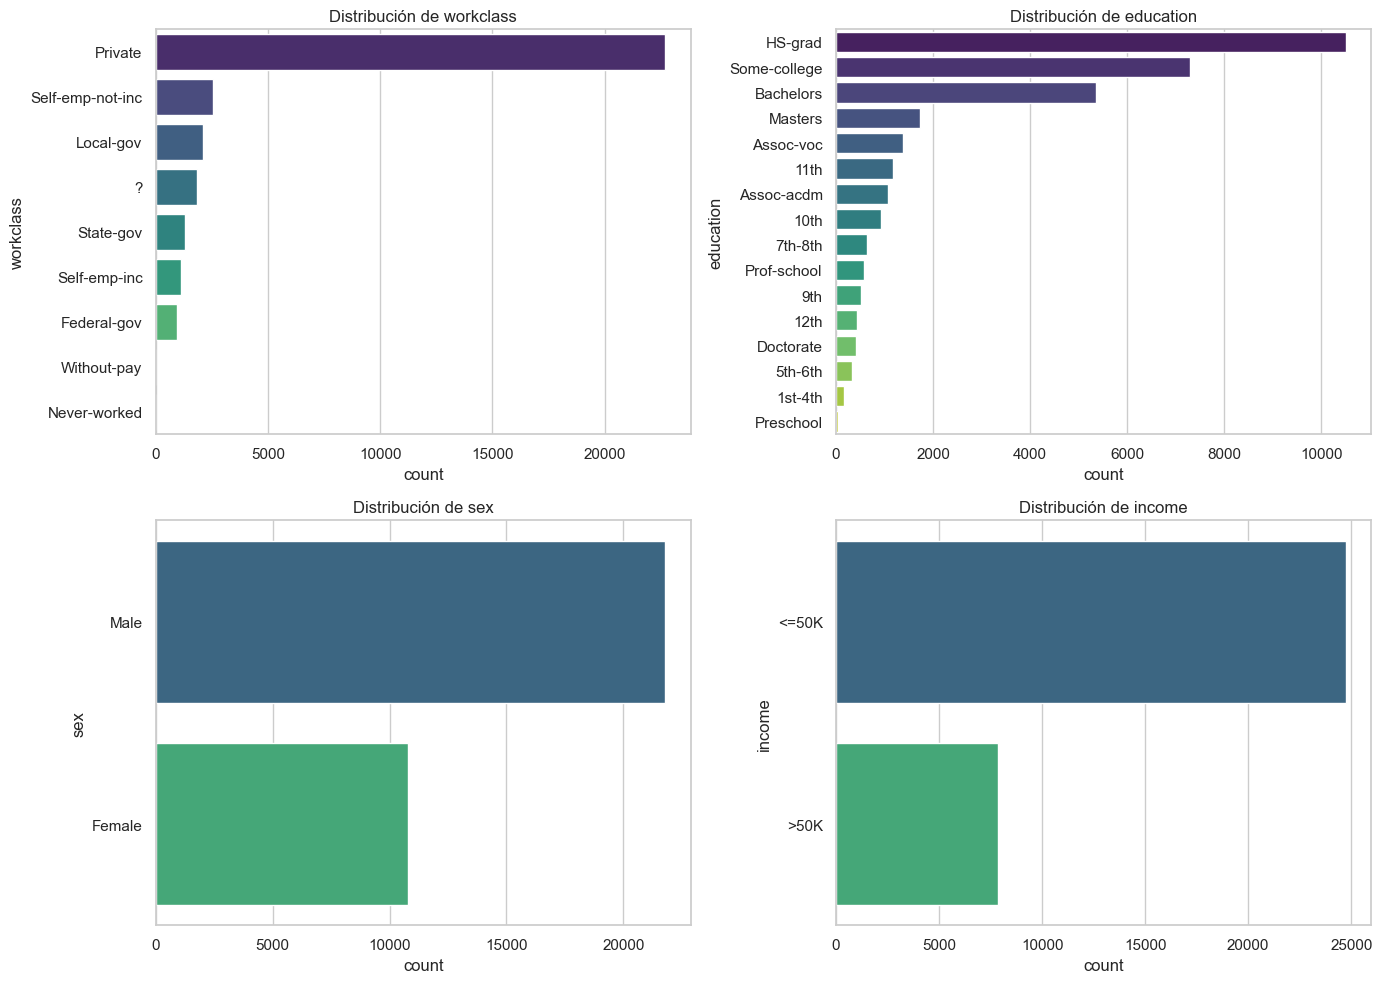

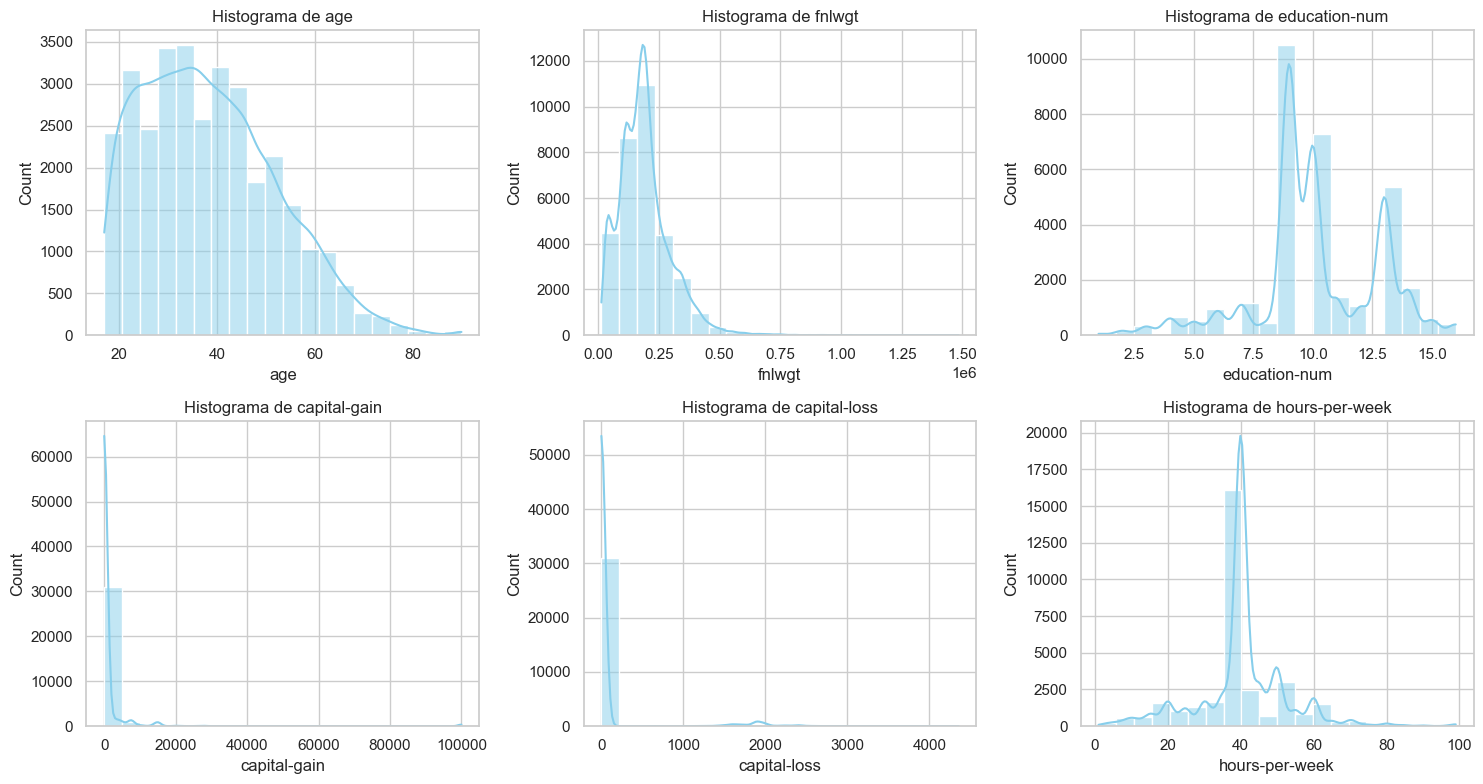

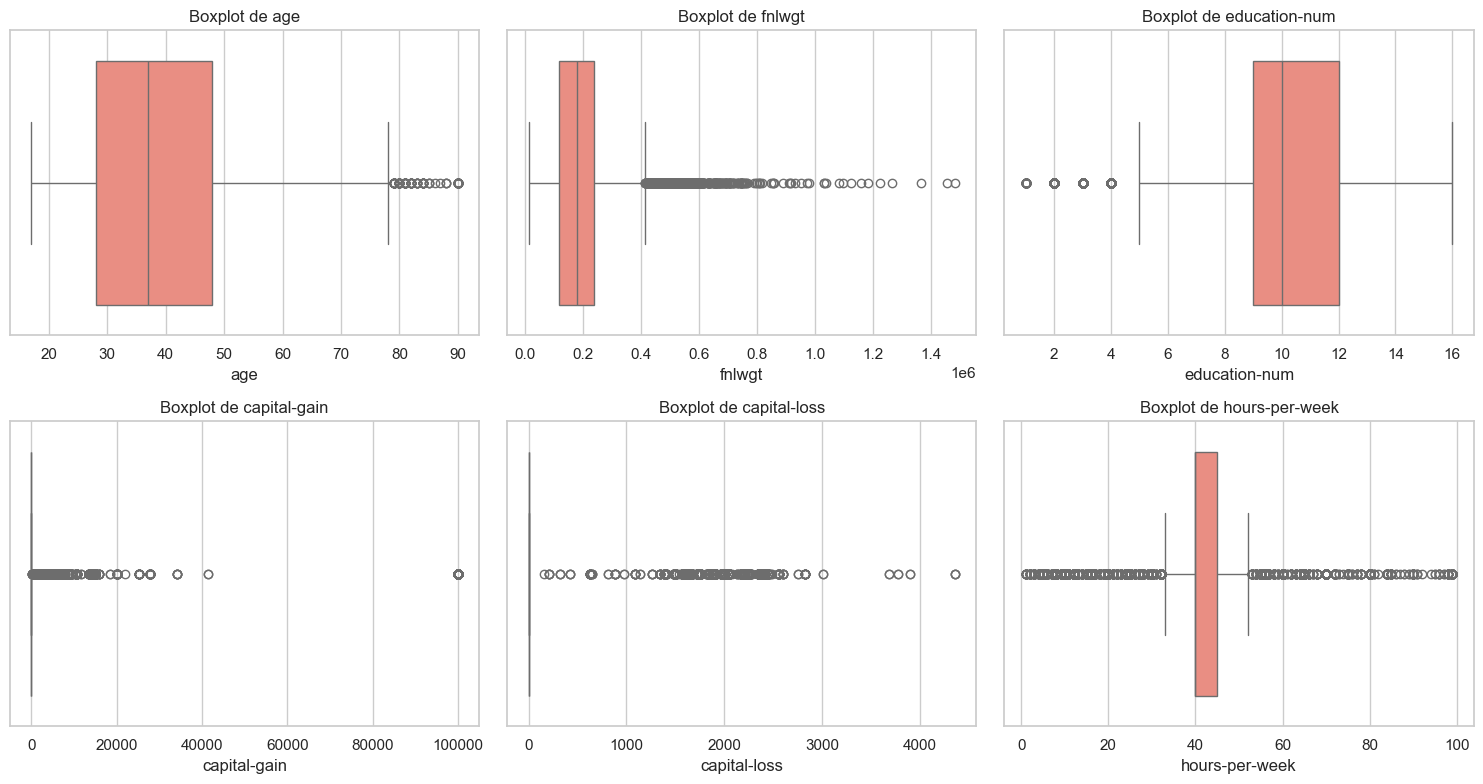

In [18]:
# Generamos las visualizaciones para las variables categóricas y numéricas:

# 1. Gráficos de barras para variables categóricas 
cols_cat_plot = ['workclass', 'education', 'sex', 'income']
plt.figure(figsize=(14, 10)) # Tamaño ajustado
for i, col in enumerate(cols_cat_plot, 1):
    plt.subplot(2, 2, i)
    sns.countplot(y=df[col], palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# 2. Histogramas para variables numéricas (Son exactamente 6 variables, encajan perfecto en un grid de 2x3)
plt.figure(figsize=(15, 8))
for i, col in enumerate(var_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f'Histograma de {col}')
plt.tight_layout()
plt.show()

# 3. Boxplots para detectar outliers en variables numéricas
plt.figure(figsize=(15, 8))
for i, col in enumerate(var_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [19]:
# 4. Codificación con get_dummies de pandas
# Genera variables binarias (0 y 1) para cada categoría. 
# drop_first=True evita la trampa de las variables ficticias (multicolinealidad).
df_dummies = pd.get_dummies(df, columns=var_categoricas, drop_first=True, dtype=int)

print("--- Resultado con get_dummies ---")
print(f"Nuevas dimensiones: {df_dummies.shape}")
display(df_dummies.head(3))

--- Resultado con get_dummies ---
Nuevas dimensiones: (32561, 101)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [20]:
# 5. Codificación con OneHotEncoder de scikit-learn
# Actualizado a sparse_output=False para compatibilidad con versiones modernas de scikit-learn
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Entrenamos y transformamos las variables categóricas
matriz_ohe = ohe.fit_transform(df[var_categoricas])

# Para visualizarlo bien, lo convertimos en DataFrame recuperando los nombres de las columnas
nombres_ohe = ohe.get_feature_names_out(var_categoricas)
df_ohe = pd.DataFrame(matriz_ohe, columns=nombres_ohe, index=df.index)

# Unimos con las variables numéricas originales
df_onehot_final = pd.concat([df[var_numericas], df_ohe], axis=1)

print("--- Resultado con OneHotEncoder ---")
print(f"Nuevas dimensiones: {df_onehot_final.shape}")
display(df_onehot_final.head(3))

--- Resultado con OneHotEncoder ---
Nuevas dimensiones: (32561, 101)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,39,77516,13,2174,0,40,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,50,83311,13,0,0,13,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38,215646,9,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [21]:
# 6. Codificación con LabelEncoder de scikit-learn
# LabelEncoder transforma cada categoría en un número entero (0, 1, 2...).
# IMPORTANTE: Se aplica de forma individual a cada columna.
df_label = df.copy()
le = LabelEncoder()

for col in var_categoricas:
    df_label[col] = le.fit_transform(df_label[col])

print("--- Resultado con LabelEncoder ---")
print(f"Nuevas dimensiones: {df_label.shape} (las dimensiones no aumentan)")
display(df_label.head(3))

--- Resultado con LabelEncoder ---
Nuevas dimensiones: (32561, 15) (las dimensiones no aumentan)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
